# Signal Learnability — Label & Feature Quality Workbench

Assess how "learnable" your signals are before committing them to model training.

**Typical workflow:**
1. Load a dataset in the **Configuration** cell
2. Tune **Label Parameters** and run **Compute Labels**
3. Review the **Signal Chart** — visual sanity check
4. Run **Signal Quality Analysis** — win rate, EV, temporal density
5. Run **Learnability Score** — composite 0–1 score with MI-driven feature separability
6. Run **Feature Quality Analysis** — per-feature MI, RF importance, SHAP, correlation
7. Run **Parameter Grid Search** — brute-force over label/regime grids, ranked results

| Section | Description |
|---|---|
| Configuration | Dataset, parameters, save/load |
| Compute Labels | Causal triple-barrier labeller + trade outcomes + regime |
| Signal Chart | Interactive candlestick with buy/sell markers and regime overlay |
| Signal Quality | Win rate, EV, class balance, temporal density, duration distributions |
| Learnability Score | Composite score: MI separability (50%), win rate (20%), balance (15%), density (15%) |
| Feature Quality | MI ranking, Random Forest importance, SHAP values, correlation heatmap, per-class distributions |
| Grid Search | Brute-force parameter grid with score heatmaps and best-config export |


In [24]:
import os, json, warnings
import pandas as pd
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from Learn.features import donchian_trend
warnings.filterwarnings('ignore')

PARAMS_FILE = 'label_params.json'   # saved in ModelWorkbench/

## Helpers

In [25]:
def load_ohlcv(ds_name, start_date=None, n_rows=None):
    """Load an OHLCV CSV, optionally sliced by start_date or tail n_rows."""
    df = pd.read_csv(ds_name)
    df = df.sort_values('Time').reset_index(drop=True)
    df['Time'] = pd.to_datetime(df['Time'])
    if start_date:
        df = df[df['Time'] > start_date].reset_index(drop=True)
    if n_rows is not None:
        df = df.tail(n_rows).reset_index(drop=True)
    return df

## Configuration

Set the dataset path and evaluation window. `TEST_DATE` trims the dataframe to only post-date rows so the chart isn't overwhelmed — set to `None` to use the full file.

In [26]:
# ── Dataset ───────────────────────────────────────────────────────────────────
DS_NAME    = '../data/XAUUSD_1minute.csv'
TEST_DATE  = '2026-01-01'   # Show bars after this date only (None = full file)

# ── Load ──────────────────────────────────────────────────────────────────────
df = load_ohlcv(DS_NAME, start_date=TEST_DATE)

print(f"Dataset: {DS_NAME.split('/')[-1]}")
print(f"Window:  {df['Time'].iloc[0]}  →  {df['Time'].iloc[-1]}")
print(f"Bars:    {len(df):,}")

Dataset: XAUUSD_1minute.csv
Window:  2026-01-01 23:01:00+00:00  →  2026-03-11 07:08:00+00:00
Bars:    66,355


## Label Parameters

Tune the regime-detection and triple-barrier labelling parameters below, then run **Compute Labels** to see updated signals on the chart.

| Group | Key Parameters |
|---|---|
| **Regime** | `ma_period`, `slope_threshold`, `atr_percentile` — controls trend detection sensitivity |
| **Labelling** | `tp_mult`, `sl_mult`, `max_horizon` — risk-reward and time limit for each label |
| **Selectivity** | `trend_pullback_thresh` — raise to label fewer, higher-quality entries; `skip_range` masks range-bound bars |

Use the **Save / Load Parameters** cell below to persist a named config to `label_params.json`.

In [27]:
# ── Instrument / Timeframe identifier (used as key in label_params.json) ──────
PARAM_KEY = 'XAUUSD_very_selective'

# ── Regime detection ─────────────────────────────────────────────────────────
regime_params = {
      "ma_period": 60,
      "slope_smoothness": 10,
      "regime_min_duration": 0,
      "atr_window": 60,
      "atr_lookback": 720,
      "atr_percentile": 0.0,
      "slope_threshold": 0.0
    }

# ── Triple-barrier labelling ──────────────────────────────────────────────────
label_params = {
      "z_window": 14,
      "z_thresh": 1,
      "z_limit": 5,
      "atr_window": 14,
      "tp_mult": 2.5,
      "sl_mult": 2.5,
      "max_horizon": 90,
      "trend_pullback_thresh": 1.0,
      "regime_params": regime_params,
      "skip_range": True
    }

# ── Outcome params (subset used for P&L simulation) ──────────────────────────
outcome_params = {k: label_params[k] for k in ['atr_window', 'tp_mult', 'sl_mult', 'max_horizon']}

print(f"Active config:  '{PARAM_KEY}'")

Active config:  'XAUUSD_very_selective'


## Save / Load Parameters

Run the **save** cell after tuning to persist the current config under `PARAM_KEY` in `label_params.json`.  
Run the **load** cell to restore a previously saved config (overwrites the params cells in memory — re-run Compute Labels afterwards).

In [28]:
def _load_all_params(path=PARAMS_FILE):
    if os.path.exists(path):
        with open(path, 'r') as f:
            return json.load(f)
    return {}

def save_params(key=PARAM_KEY, path=PARAMS_FILE):
    """Persist current regime_params + label_params under `key` in the JSON file."""
    store = _load_all_params(path)
    store[key] = {
        'regime_params': regime_params,
        'label_params':  {k: v for k, v in label_params.items() if k != 'regime_params'},
    }
    with open(path, 'w') as f:
        json.dump(store, f, indent=2)
    print(f"Saved '{key}' → {path}  ({len(store)} entries total)")
    print("Keys:", list(store.keys()))

def load_params(key=PARAM_KEY, path=PARAMS_FILE):
    """Load a named config from the JSON file into the current session."""
    global regime_params, label_params, outcome_params
    store = _load_all_params(path)
    if key not in store:
        print(f"Key '{key}' not found in {path}. Available: {list(store.keys())}")
        return
    entry = store[key]
    regime_params = entry['regime_params']
    label_params  = {**entry['label_params'], 'regime_params': regime_params}
    outcome_params = {k: label_params[k] for k in ['atr_window', 'tp_mult', 'sl_mult', 'max_horizon']}
    print(f"Loaded '{key}' from {path}")
    return entry

# ── Uncomment the action you want ────────────────────────────────────────────
save_params()
# load_params()

Saved 'XAUUSD_very_selective' → label_params.json  (10 entries total)
Keys: ['US500_1m', 'EURUSD_1m', 'EURUSD_5m', 'EURUSD_1m1:1', 'US500_1m1:1', 'US500_1m_fastma_selective', 'XAUUSD', 'XAUUSD_very_selective', 'US500_very_selective', 'XAUUSD_prod']


## Compute Labels

Runs the causal triple-barrier labeller, the trade-outcome calculator, and the regime detector. Re-run this cell after changing any parameter above.

In [29]:
from Learn.labels import (
    causal_triple_barrier_hilow_trend_labeler,
    causal_market_regime,
    super_smoother,
    calculate_trade_outcomes_all_candles,
)
from talib import EMA, ATR

# ── Labels ────────────────────────────────────────────────────────────────────
df_signals = causal_triple_barrier_hilow_trend_labeler(df.copy(), **label_params).rename(columns={'side': 'target'})
winning_trades = df_signals[df_signals['label'] == 1]
df['target'] = 0
df.loc[winning_trades.index, 'target'] = winning_trades['target']

counts = df['target'].value_counts()
n_buy  = counts.get( 1, 0)
n_sell = counts.get(-1, 0)
n_hold = counts.get( 0, 0)
print(f"Labels — BUY: {n_buy:,}  SELL: {n_sell:,}  HOLD: {n_hold:,}  "
      f"({(n_buy + n_sell) / len(df) * 100:.2f}% active)")

# ── Trade outcomes ────────────────────────────────────────────────────────────
df_outcomes = calculate_trade_outcomes_all_candles(df, **outcome_params)

# ── Regime & slope ────────────────────────────────────────────────────────────
df['Centered_MA']   = EMA(df['Close'], timeperiod=regime_params['ma_period'])
df['Regime']        = causal_market_regime(df, **regime_params)
slope               = df['Centered_MA'].diff()
df['slope_sm']      = super_smoother(slope, regime_params['slope_smoothness'])
df['donchain_trend'] = donchian_trend(df, length=regime_params['atr_window'])

regime_counts = df['Regime'].value_counts().rename({1: 'Up', 0: 'Range', -1: 'Down'})
print(f"Regime   — {dict(regime_counts)}")

Labels — BUY: 1,569  SELL: 1,440  HOLD: 63,346  (4.53% active)
Regime   — {'Up': np.int64(35177), 'Down': np.int64(28968), 'Range': np.int64(2210)}


## Signal Chart

Interactive candlestick chart showing:
- **▲ Green triangle (below bar)** — BUY label
- **▼ Red triangle (above bar)** — SELL label
- **Regime-coloured MA** — green (uptrend), red (downtrend), black (range)
- **Smoothed slope** and **Donchian trend** panels for regime diagnosis

In [30]:
# from talib import ATR

# buy_bars  = df[df['target'] ==  1]
# sell_bars = df[df['target'] == -1]

# # Calculate ATR
# df['ATR'] = ATR(df['High'], df['Low'], df['Close'], timeperiod=label_params['atr_window'])

# fig = make_subplots(
#     rows=2, cols=1, shared_xaxes=True,
#     row_heights=[0.7, 0.3],
#     vertical_spacing=0.02,
# )

# # ── Candlesticks ──────────────────────────────────────────────────────────────
# fig.add_trace(go.Candlestick(
#     x=df['Time'],
#     open=df['Open'], high=df['High'],
#     low=df['Low'],   close=df['Close'],
#     name='OHLCV',
#     increasing_line_color='#26a69a', decreasing_line_color='#ef5350',
#     increasing_fillcolor='#26a69a',  decreasing_fillcolor='#ef5350',
#     line=dict(width=1),
#     hoverinfo='skip',
# ), row=1, col=1)

# # ── ATR Bands (Upper & Lower) ─────────────────────────────────────────────────
# atr_mult = label_params['tp_mult']
# df['Upper_Band'] = df['Close'] + df['ATR'] * atr_mult
# df['Lower_Band'] = df['Close'] - df['ATR'] * atr_mult

# fig.add_trace(go.Scatter(
#     x=df['Time'], y=df['Upper_Band'],
#     mode='lines',
#     line=dict(width=1, color='rgba(0, 230, 118, 0.3)', dash='dot'),
#     name=f'TP Upper ({atr_mult}×ATR)',
#     hoverinfo='skip',
# ), row=1, col=1)

# fig.add_trace(go.Scatter(
#     x=df['Time'], y=df['Lower_Band'],
#     mode='lines',
#     line=dict(width=1, color='rgba(255, 23, 68, 0.3)', dash='dot'),
#     name=f'TP Lower ({atr_mult}×ATR)',
#     hoverinfo='skip',
# ), row=1, col=1)

# # ── BUY markers ───────────────────────────────────────────────────────────────
# fig.add_trace(go.Scatter(
#     x=buy_bars['Time'], y=buy_bars['Low'],
#     mode='markers',
#     marker=dict(symbol='triangle-up', size=14, color='#00e676',
#                 line=dict(color='darkgreen', width=0.8)),
#     name='BUY label',
#     hoverinfo='skip',
# ), row=1, col=1)

# # ── SELL markers ──────────────────────────────────────────────────────────────
# fig.add_trace(go.Scatter(
#     x=sell_bars['Time'], y=sell_bars['High'],
#     mode='markers',
#     marker=dict(symbol='triangle-down', size=14, color='#ff1744',
#                 line=dict(color='darkred', width=0.8)),
#     name='SELL label',
#     hoverinfo='skip',
# ), row=1, col=1)

# # ── Regime-coloured MA ────────────────────────────────────────────────────────
# for regime_val, color, label in [(1, '#26a69a', 'Uptrend'), (0, '#888888', 'Range'), (-1, '#ef5350', 'Downtrend')]:
#     fig.add_trace(go.Scatter(
#         x=df['Time'],
#         y=df['Centered_MA'].where(df['Regime'] == regime_val),
#         mode='lines', line=dict(width=2, color=color), name=label,
#         hoverinfo='skip',
#     ), row=1, col=1)

# # ── Slope & Donchian panels ───────────────────────────────────────────────────
# fig.add_trace(go.Scatter(
#     x=df['Time'], y=df['slope_sm'],
#     mode='lines', line=dict(width=1, color='#82aaff'), name='Smoothed Slope',
#     hoverinfo='skip',
# ), row=2, col=1)

# fig.add_trace(go.Scatter(
#     x=df['Time'], y=df['donchain_trend'],
#     mode='lines', line=dict(width=1, color='#ffcb6b'), name='Donchian Trend',
#     hoverinfo='skip',
# ), row=2, col=1)

# # ── Layout ────────────────────────────────────────────────────────────────────
# title_str = (
#     f"{DS_NAME.split('/')[-1].replace('.csv','')}  |  "
#     f"BUY: {len(buy_bars):,}   SELL: {len(sell_bars):,}   "
#     f"({(len(buy_bars) + len(sell_bars)) / len(df) * 100:.2f}% active)  |  "
#     f"Config: {PARAM_KEY}"
# )

# fig.update_layout(
#     title=dict(text=title_str, font_size=13),
#     xaxis_rangeslider_visible=False,
#     xaxis2=dict(title='Time'),
#     yaxis=dict(title='Price', fixedrange=False),
#     yaxis2=dict(title='Indicator'),
#     legend=dict(orientation='h', yanchor='bottom', y=1.02, xanchor='right', x=1),
#     height=1000,
#     margin=dict(l=60, r=20, t=80, b=60),
#     hovermode=False,
#     paper_bgcolor='#1e1e1e',
#     plot_bgcolor='#1e1e1e',
#     font=dict(color='#d4d4d4'),
#     xaxis_gridcolor='#333',
#     yaxis_gridcolor='#333',
#     xaxis2_gridcolor='#333',
#     yaxis2_gridcolor='#333',
# )

# fig.show()

## Signal Quality Analysis

Quantitative breakdown of signal distribution, win rate, expected value, and temporal concentration.  
Re-run this section after changing **Label Parameters** to compare configurations side-by-side.

> Requires the **Compute Labels** cell to have been executed first.


In [31]:
import warnings
warnings.filterwarnings('ignore')

# ── Core stats ─────────────────────────────────────────────────────────────────
# df_signals columns: target (direction), label (1=TP,-1=SL,0=timeout), z, regime, tp, sl, t_end
buy_sig  = df_signals[df_signals['target'] ==  1]
sell_sig = df_signals[df_signals['target'] == -1]
winning  = df_signals[df_signals['label'] ==  1]
losing   = df_signals[df_signals['label'] == -1]
timeout  = df_signals[df_signals['label'] ==  0]

total     = len(df_signals)
density   = total / len(df) * 100
bs_ratio  = len(buy_sig) / len(sell_sig) if len(sell_sig) > 0 else float('nan')

def _wr(subset):
    return (subset['label'] == 1).sum() / len(subset) if len(subset) > 0 else float('nan')

wr_overall = _wr(df_signals)
wr_buy     = _wr(buy_sig)
wr_sell    = _wr(sell_sig)

ev  = wr_overall * label_params['tp_mult'] - (1 - wr_overall) * label_params['sl_mult']
rr  = label_params['tp_mult'] / label_params['sl_mult']

durations = df_signals['t_end'] - df_signals.index
win_dur   = durations[winning.index].mean() if len(winning) else float('nan')
loss_dur  = durations[losing.index].mean()  if len(losing)  else float('nan')

# Wins by regime
if 'regime' in df_signals.columns:
    _win_by_regime = (
        winning.groupby('regime').size()
               .rename(index={1: 'Up', 0: 'Range', -1: 'Down'})
               .to_dict()
    )
else:
    _win_by_regime = {}

print("=" * 60)
print("  SIGNAL QUALITY SUMMARY")
print("=" * 60)
print(f"  Total signals   : {total:,}  ({density:.2f}% density)")
print(f"  Buy signals     : {len(buy_sig):,}  |  Sell: {len(sell_sig):,}  |  B/S: {bs_ratio:.2f}x")
print(f"  Win rate        : {wr_overall:.1%}  (buy {wr_buy:.1%}  /  sell {wr_sell:.1%})")
print(f"  TP / SL / Exp.  : {len(winning):,} / {len(losing):,} / {len(timeout):,}")
print(f"  Expected Value  : {ev:+.3f}R  (RR = {rr:.1f}:1)")
print(f"  Avg win bars    : {win_dur:.1f}  |  Avg loss bars: {loss_dur:.1f}")
if _win_by_regime:
    print(f"  Wins by regime  : {_win_by_regime}")
print("=" * 60)

# ── Automated assessment ───────────────────────────────────────────────────────
notes = []
if wr_overall < 0.45:
    notes.append(f"✗  Win rate ({wr_overall:.1%}) below {rr:.1f}:1 breakeven — signals may be noise")
elif wr_overall >= 0.65:
    notes.append(f"✓  Win rate ({wr_overall:.1%}) is strong for a {rr:.1f}:1 strategy")
if density < 0.5:
    notes.append(f"⚠  Signal density ({density:.2f}%) is very low — model will see few positives per epoch")
elif density > 10:
    notes.append(f"⚠  Signal density ({density:.2f}%) is high — check for over-labelling")
if np.isfinite(bs_ratio) and abs(1 - bs_ratio) > 0.5:
    notes.append(f"⚠  Buy/sell imbalance ({bs_ratio:.2f}x) — consider separate directional models")
if ev < 0:
    notes.append(f"✗  Negative EV ({ev:+.3f}R) — raise tp_mult, lower sl_mult, or tighten entry criteria")
elif ev > label_params['sl_mult']:
    notes.append(f"✓  Strong positive EV ({ev:+.3f}R)")

for note in notes:
    print(f"  {note}")


  SIGNAL QUALITY SUMMARY
  Total signals   : 8,727  (13.15% density)
  Buy signals     : 4,767  |  Sell: 3,960  |  B/S: 1.20x
  Win rate        : 34.5%  (buy 32.9%  /  sell 36.4%)
  TP / SL / Exp.  : 3,009 / 5,630 / 88
  Expected Value  : -0.776R  (RR = 1.0:1)
  Avg win bars    : 19.2  |  Avg loss bars: 14.0
  Wins by regime  : {'Down': 1440, 'Up': 1569}
  ✗  Win rate (34.5%) below 1.0:1 breakeven — signals may be noise
  ⚠  Signal density (13.15%) is high — check for over-labelling
  ✗  Negative EV (-0.776R) — raise tp_mult, lower sl_mult, or tighten entry criteria


In [32]:
# ── Signal Quality Charts ──────────────────────────────────────────────────────
win_durations  = (df_signals.loc[winning.index, 't_end'] - winning.index).clip(lower=0)
loss_durations = (df_signals.loc[losing.index,  't_end'] - losing.index).clip(lower=0)

fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=[
        'Win Rate by Regime',
        'Trade Duration Distribution (bars)',
        'Signal Temporal Density (rolling 500 bars)',
        'Z-Score at Entry: TP vs SL',
    ],
    vertical_spacing=0.14, horizontal_spacing=0.10,
)

# ─ Win rate by regime ──────────────────────────────────────────────────────────
if 'regime' in df_signals.columns:
    for rv, rname, rc in [(1,'Up','#26a69a'), (0,'Range','#aaaaaa'), (-1,'Down','#ef5350')]:
        sub = df_signals[df_signals['regime'] == rv]
        if len(sub) == 0:
            continue
        fig.add_trace(go.Bar(name=rname, x=[rname], y=[(sub['label']==1).mean()],
                             marker_color=rc, showlegend=True), row=1, col=1)

# ─ Duration histogram ──────────────────────────────────────────────────────────
if len(win_durations):
    fig.add_trace(go.Histogram(x=win_durations, nbinsx=30, name='TP trades',
                               marker_color='#26a69a', opacity=0.7, showlegend=True), row=1, col=2)
if len(loss_durations):
    fig.add_trace(go.Histogram(x=loss_durations, nbinsx=30, name='SL trades',
                               marker_color='#ef5350', opacity=0.7, showlegend=True), row=1, col=2)

# ─ Temporal density (rolling 500 bars) ─────────────────────────────────────────
_ROLL = 500
_sig_series              = pd.Series(0, index=df.index)
_sig_series.loc[df.index[df['target'] != 0]] = 1
_rolling_density         = _sig_series.rolling(_ROLL).mean() * 100

fig.add_trace(go.Scatter(x=df['Time'], y=_rolling_density, mode='lines',
                         line=dict(color='#82aaff', width=1.2), name='Signal Density %',
                         showlegend=True), row=2, col=1)
fig.add_hline(y=density, line_dash='dot', line_color='rgba(255,255,255,0.5)',
              annotation_text=f'Mean {density:.2f}%', row=2, col=1)

# ─ Z-score at entry ─────────────────────────────────────────────────────────────
if 'z' in df_signals.columns:
    if len(winning):
        fig.add_trace(go.Histogram(x=winning['z'].clip(-4, 4), nbinsx=40, name='TP z',
                                   marker_color='#26a69a', opacity=0.7, showlegend=True), row=2, col=2)
    if len(losing):
        fig.add_trace(go.Histogram(x=losing['z'].clip(-4, 4), nbinsx=40, name='SL z',
                                   marker_color='#ef5350', opacity=0.7, showlegend=True), row=2, col=2)

fig.update_layout(
    height=700,
    title=dict(text=f'Signal Quality Charts — {PARAM_KEY}', font_size=13),
    paper_bgcolor='#1e1e1e', plot_bgcolor='#1e1e1e', font=dict(color='#d4d4d4'),
    barmode='overlay',
    legend=dict(orientation='h', yanchor='bottom', y=1.02, xanchor='right', x=1),
    margin=dict(l=60, r=20, t=80, b=40),
)
for _ax in ['xaxis','yaxis','xaxis2','yaxis2','xaxis3','yaxis3','xaxis4','yaxis4']:
    fig.update_layout(**{_ax: dict(gridcolor='#333')})
fig.show()


## Learnability Score

Measures how well the current feature set can separate signal bars from the background noise.

**Composite score (0–1):**

| Component | Weight | Description |
|---|---|---|
| MI separability | 50% | Mean MI of top-20 features vs shuffled-label baseline |
| Win rate | 20% | Piecewise: 0 at ≤50%, 1 at ≥70% |
| Class balance | 15% | 1 if buy/sell perfectly balanced, degrades with skew |
| Signal density | 15% | Peaks around 2% density; penalises very sparse or dense signals |

A score above **0.4** indicates reasonable learnability. Above **0.6** is strong and suitable for model training.

> Requires the **Compute Labels** cell to have been run.  
> Set `_INCLUDE_MTF = True` below if your model uses MTF features (adds compute time).


In [33]:
import time
from sklearn.feature_selection import mutual_info_classif
from Learn.features import add_selected_features
from Learn.preprocess import preprocess_ohlcv

# ── Config ─────────────────────────────────────────────────────────────────────
_INCLUDE_MTF = False    # set True to include multi-timeframe features (slower)

# ── Build feature matrix ────────────────────────────────────────────────────────
print("Building feature matrix …")
_t0 = time.time()
_df_feat = add_selected_features(df.copy(), include_mtf=_INCLUDE_MTF)
_df_feat['target'] = df['target']   # carry winning-signal labels through

print(f"  Raw columns   : {_df_feat.shape[1]}  |  Rows: {len(_df_feat):,}  |  {time.time()-_t0:.1f}s")

# ── Preprocess (shift=0: features at bar t predict signal label at bar t) ──────
X_learn, y_learn, _scaler_learn, feature_cols_learn = preprocess_ohlcv(
    _df_feat, target_col='target', shift=0
)
print(f"  Feature matrix: {X_learn.shape[0]:,} rows × {X_learn.shape[1]} features")
print(f"  Signal rows   : {(y_learn != 0).sum():,}  ({(y_learn != 0).mean()*100:.2f}% of rows)")

# ── Binary target: signal vs no-signal ─────────────────────────────────────────
y_bin_learn = (y_learn != 0).astype(int)

# ── Mutual Information ──────────────────────────────────────────────────────────
print("\nComputing Mutual Information …")
_t0 = time.time()
mi_scores_learn = mutual_info_classif(X_learn, y_bin_learn, discrete_features=False, random_state=42)
print(f"  Done in {time.time()-_t0:.1f}s")

# ── Shuffled-label baseline (random reference for MI normalization) ─────────────
_y_shuf = y_bin_learn.copy()
np.random.default_rng(0).shuffle(_y_shuf)
_mi_base = mutual_info_classif(X_learn, _y_shuf, discrete_features=False, random_state=42)
_baseline_mean = np.mean(np.sort(_mi_base)[::-1][:20])

# ── MI results dataframe ────────────────────────────────────────────────────────
mi_df_learn = (
    pd.DataFrame({'feature': feature_cols_learn, 'mi': mi_scores_learn})
    .sort_values('mi', ascending=False)
    .reset_index(drop=True)
)

print(f"\nTop 10 features by MI:")
print(mi_df_learn.head(10).to_string(index=False))


Building feature matrix …
  Raw columns   : 67  |  Rows: 66,355  |  1.2s
  Feature matrix: 66,099 rows × 59 features
  Signal rows   : 3,000  (4.54% of rows)

Computing Mutual Information …
  Done in 22.0s

Top 10 features by MI:
               feature       mi
                     z 0.033464
           Centered_MA 0.022733
        roll_range_256 0.020949
close_detrended_64_atr 0.019221
                OH_CCI 0.012105
            OH_z_flag2 0.011626
                Regime 0.011381
     donchian_pressure 0.011110
                 z_128 0.010086
        donchain_trend 0.009171


In [34]:
# ── Learnability Score Calculation ─────────────────────────────────────────────
_K_TOP = 20
_top_k_mi = mi_df_learn['mi'].head(_K_TOP).mean()

# MI score: 1.0 if top-K mean MI is ≥10× baseline; linear below
_ref = max(_baseline_mean, 1e-6)
mi_score_learn = min(_top_k_mi / (_ref * 10), 1.0)

# Win-rate score: piecewise 0 @ ≤50%, 1 @ ≥70%
wr_score_learn = max(0.0, min(1.0, (wr_overall - 0.50) / 0.20))

# Balance score: 1.0 = perfect, degrades with buy/sell skew
bal_score_learn = (1.0 - min(abs(bs_ratio - 1.0) / 2.0, 1.0)) if np.isfinite(bs_ratio) else 0.5

# Density score: peaks at 2–5%, penalises extremes
if   density < 0.2:      den_score_learn = density / 0.2
elif density <= 2.0:     den_score_learn = 0.5 + 0.5 * (density - 0.2) / 1.8
elif density <= 5.0:     den_score_learn = 1.0
elif density <= 15.0:    den_score_learn = 1.0 - (density - 5.0) / 10.0
else:                    den_score_learn = 0.0

# Composite (weights: MI=50%, WR=20%, balance=15%, density=15%)
learnability_score = (
    0.50 * mi_score_learn +
    0.20 * wr_score_learn +
    0.15 * bal_score_learn +
    0.15 * den_score_learn
)

_components = {
    'MI separability (50%)':  (mi_score_learn,  0.50),
    'Win rate (20%)':         (wr_score_learn,  0.20),
    'Class balance (15%)':    (bal_score_learn, 0.15),
    'Signal density (15%)':   (den_score_learn, 0.15),
}

print(f"\n{'='*55}")
print(f"  LEARNABILITY SCORE:  {learnability_score:.3f} / 1.000")
print(f"{'='*55}")
for _name, (_raw, _w) in _components.items():
    _bar = '█' * int(_raw * 20)
    print(f"  {_name:<26} {_raw:.3f}  [{_bar:<20}]  → {_raw*_w:.3f}")
print(f"{'='*55}")
print(f"  top-{_K_TOP} MI mean: {_top_k_mi:.5f}  |  baseline: {_baseline_mean:.5f}  |  ratio: {_top_k_mi/max(_baseline_mean,1e-9):.1f}×")

if learnability_score >= 0.6:
    print(f"\n  ✓  Strong learnability — good candidate for model training")
elif learnability_score >= 0.4:
    print(f"\n  ~  Moderate learnability — review the weakest components above")
else:
    print(f"\n  ✗  Low learnability — tune label params or enrich the feature set before training")

# ── Breakdown chart ─────────────────────────────────────────────────────────────
_comp_names = list(_components.keys())
_raw_vals   = [v[0] for v in _components.values()]
_weighted   = [v[0]*v[1] for v in _components.values()]
_colors     = ['#82aaff', '#c3e88d', '#ffcb6b', '#f78c6c']

fig = go.Figure()
fig.add_trace(go.Bar(
    x=_comp_names, y=_raw_vals, name='Raw Score (0–1)',
    marker_color=_colors, opacity=0.5,
    text=[f'{v:.3f}' for v in _raw_vals], textposition='outside',
))
fig.add_trace(go.Bar(
    x=_comp_names, y=_weighted, name='Weighted Contribution',
    marker_color=_colors, opacity=1.0,
    text=[f'{v:.3f}' for v in _weighted], textposition='inside',
))
fig.add_hline(y=learnability_score, line_dash='dash', line_color='white',
              annotation_text=f'Composite: {learnability_score:.3f}',
              annotation_position='top right')

fig.update_layout(
    title=f'Learnability Score Breakdown — {learnability_score:.3f} / 1.00  ({PARAM_KEY})',
    yaxis=dict(range=[0, 1.15], title='Score', gridcolor='#333'),
    xaxis=dict(gridcolor='#333'),
    barmode='overlay',
    height=420,
    paper_bgcolor='#1e1e1e', plot_bgcolor='#1e1e1e', font=dict(color='#d4d4d4'),
    legend=dict(orientation='h', yanchor='bottom', y=1.02, xanchor='right', x=1),
    margin=dict(l=60, r=20, t=60, b=40),
)
fig.show()



  LEARNABILITY SCORE:  0.401 / 1.000
  MI separability (50%)      0.478  [█████████           ]  → 0.239
  Win rate (20%)             0.000  [                    ]  → 0.000
  Class balance (15%)        0.898  [█████████████████   ]  → 0.135
  Signal density (15%)       0.185  [███                 ]  → 0.028
  top-20 MI mean: 0.01066  |  baseline: 0.00223  |  ratio: 4.8×

  ~  Moderate learnability — review the weakest components above


## Feature Quality Analysis

Deep-dive into how useful each feature is from the model's perspective.

| Sub-section | What it shows |
|---|---|
| Feature Summary | NaN%, variance, mean after scaling — flags low-variance features |
| MI Ranking | Top-30 features by Mutual Information with the signal label |
| RF Importance | Random Forest feature importance (100 trees) — complements MI |
| SHAP Values | Direction-aware importance via SHAP (requires `pip install shap`) |
| Correlation Heatmap | Pairs with \|r\| > 0.85 are redundant candidates for removal |
| Per-class Distributions | Violin plots for top-10 MI features split by buy / sell / no-signal |

> Requires the **Learnability Score** section to have been run first (`X_learn`, `y_learn`, `feature_cols_learn`).


In [35]:
# ── Feature Summary Table ───────────────────────────────────────────────────────
feat_summary = pd.DataFrame({
    'feature': feature_cols_learn,
    'mi':      mi_scores_learn,
    'std':     X_learn.std(axis=0),
    'mean':    X_learn.mean(axis=0),
    'nan_pct': np.isnan(X_learn).mean(axis=0) * 100,
}).sort_values('mi', ascending=False).reset_index(drop=True)
feat_summary.index += 1   # 1-based MI rank

_low_var = feat_summary[feat_summary['std'] < 0.01]
if len(_low_var):
    print(f"⚠  Low-variance features (std < 0.01, {len(_low_var)}):")
    print(f"   {_low_var['feature'].tolist()}")
else:
    print("✓  No low-variance features detected")

_high_nan = feat_summary[feat_summary['nan_pct'] > 5]
if len(_high_nan):
    print(f"⚠  High-NaN features (>5%, {len(_high_nan)}):")
    print(f"   {_high_nan['feature'].tolist()}")
else:
    print("✓  No high-NaN features detected")

print(f"\nFeature summary (top 20 by MI):")
print(feat_summary[['feature','mi','std','mean','nan_pct']].head(20).to_string())

# ── MI Bar Chart ─────────────────────────────────────────────────────────────────
_N_SHOW = min(30, len(feat_summary))
_top_mi = feat_summary.head(_N_SHOW)
_mi_max = _top_mi['mi'].max()
_bar_colors = [f'rgba(130,170,255,{0.35 + 0.65 * v / _mi_max:.2f})' for v in _top_mi['mi']]

fig = go.Figure(go.Bar(
    y=_top_mi['feature'][::-1],
    x=_top_mi['mi'][::-1],
    orientation='h',
    marker_color=_bar_colors[::-1],
    text=[f'{v:.4f}' for v in _top_mi['mi'][::-1]],
    textposition='outside',
))
fig.update_layout(
    title=f'Mutual Information — Top {_N_SHOW} Features (signal vs no-signal)',
    height=max(400, _N_SHOW * 22),
    xaxis=dict(title='MI Score', gridcolor='#333'),
    yaxis=dict(automargin=True, gridcolor='#333'),
    paper_bgcolor='#1e1e1e', plot_bgcolor='#1e1e1e', font=dict(color='#d4d4d4'),
    margin=dict(l=180, r=80, t=60, b=40),
)
fig.show()


⚠  Low-variance features (std < 0.01, 5):
   ['cumret_15_norm', 'direction_confidence', 'cumret_60_norm', 'slope_30_norm', 'C_rel']
✓  No high-NaN features detected

Feature summary (top 20 by MI):
                   feature        mi       std      mean  nan_pct
1                        z  0.033464  0.615256 -0.034251      0.0
2              Centered_MA  0.022733  0.586744 -0.145582      0.0
3           roll_range_256  0.020949  1.344898  0.444542      0.0
4   close_detrended_64_atr  0.019221  0.723878  0.017062      0.0
5                   OH_CCI  0.012105  0.635882  0.023056      0.0
6               OH_z_flag2  0.011626  0.424844  0.236358      0.0
7                   Regime  0.011381  0.978832  0.091938      0.0
8        donchian_pressure  0.011110  0.655509  0.023593      0.0
9                    z_128  0.010086  1.388455  0.133315      0.0
10          donchain_trend  0.009171  0.996208  0.087006      0.0
11              OH_z_flag1  0.007654  0.443875  0.269838      0.0
12        

In [13]:
# ── Random Forest Feature Importance ───────────────────────────────────────────
from sklearn.ensemble import RandomForestClassifier

_MAX_RF_ROWS = 50_000
if len(X_learn) > _MAX_RF_ROWS:
    _idx_rf = np.random.default_rng(42).choice(len(X_learn), _MAX_RF_ROWS, replace=False)
    _X_rf, _y_rf = X_learn[_idx_rf], y_bin_learn[_idx_rf]
else:
    _X_rf, _y_rf = X_learn, y_bin_learn

print(f"Training RF on {len(_X_rf):,} rows …")
_t0 = time.time()
_rf = RandomForestClassifier(n_estimators=100, max_depth=8, n_jobs=-1, random_state=42)
_rf.fit(_X_rf, _y_rf)
print(f"  Done in {time.time()-_t0:.1f}s")

_rf_imp_df = (
    pd.DataFrame({'feature': feature_cols_learn, 'rf_importance': _rf.feature_importances_, 'mi': mi_scores_learn})
    .sort_values('rf_importance', ascending=False)
    .reset_index(drop=True)
)

# Overlap between top-10 MI and top-10 RF
_top10_mi = set(mi_df_learn.head(10)['feature'])
_top10_rf = set(_rf_imp_df.head(10)['feature'])
_overlap  = _top10_mi & _top10_rf
print(f"\nTop-10 MI ∩ RF overlap: {len(_overlap)}/10 — {sorted(_overlap)}")
print(f"\nTop 10 features by RF importance:")
print(_rf_imp_df[['feature','rf_importance','mi']].head(10).to_string(index=False))

_N_RF  = min(30, len(_rf_imp_df))
_top_rf = _rf_imp_df.head(_N_RF)

fig = go.Figure(go.Bar(
    y=_top_rf['feature'][::-1],
    x=_top_rf['rf_importance'][::-1],
    orientation='h',
    marker_color='rgba(255,203,107,0.85)',
    text=[f'{v:.4f}' for v in _top_rf['rf_importance'][::-1]],
    textposition='outside',
))
fig.update_layout(
    title=f'Random Forest Feature Importance — Top {_N_RF}',
    height=max(400, _N_RF * 22),
    xaxis=dict(title='RF Importance', gridcolor='#333'),
    yaxis=dict(automargin=True, gridcolor='#333'),
    paper_bgcolor='#1e1e1e', plot_bgcolor='#1e1e1e', font=dict(color='#d4d4d4'),
    margin=dict(l=180, r=80, t=60, b=40),
)
fig.show()


Training RF on 50,000 rows …
  Done in 2.1s

Top-10 MI ∩ RF overlap: 4/10 — ['Regime', 'slope_60', 'slope_sm', 'z']

Top 10 features by RF importance:
      feature  rf_importance       mi
            z       0.109537 0.018148
       Regime       0.098747 0.021699
     slope_sm       0.097683 0.019925
   OH_z_flag2       0.046487 0.005893
 vwap_diff_64       0.036434 0.001064
       OH_CCI       0.034198 0.006866
    PR_EMA_21       0.033727 0.000000
   OH_z_flag1       0.032463 0.004257
slope_30_norm       0.031228 0.001929
     slope_60       0.025822 0.009943


Computing SHAP values on 2000 samples …
  Done in 6.5s


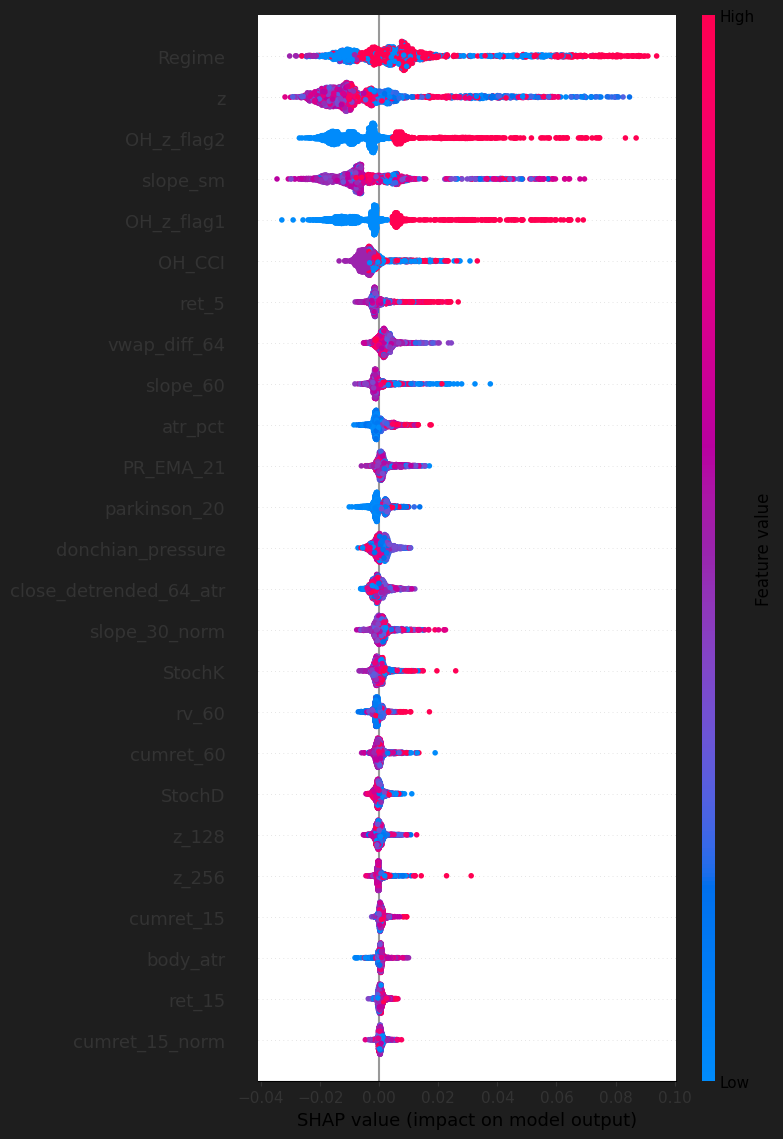


Top 10 features by mean |SHAP|:
     feature  mean_abs_shap
      Regime       0.016011
           z       0.015142
  OH_z_flag2       0.010923
    slope_sm       0.010378
  OH_z_flag1       0.009038
      OH_CCI       0.004811
       ret_5       0.002513
vwap_diff_64       0.002450
    slope_60       0.002324
     atr_pct       0.002034


In [36]:
# ── SHAP Values ─────────────────────────────────────────────────────────────────
try:
    import shap
    import matplotlib.pyplot as plt

    _SHAP_N = min(2000, len(X_learn))
    _idx_shap = np.random.default_rng(99).choice(len(X_learn), _SHAP_N, replace=False)
    _X_shap   = X_learn[_idx_shap]

    print(f"Computing SHAP values on {_SHAP_N} samples …")
    _t0 = time.time()
    _explainer   = shap.TreeExplainer(_rf)
    _shap_values = _explainer.shap_values(_X_shap)
    print(f"  Done in {time.time()-_t0:.1f}s")

    # Handle both old SHAP API (list of arrays) and new API (single ndarray):
    #   old: list[class0_arr, class1_arr]  each (n_samples, n_features)
    #   new: ndarray (n_samples, n_features, n_classes)  OR  (n_samples, n_features)
    if isinstance(_shap_values, list):
        _sv = _shap_values[1]              # class 1 = signal
    elif hasattr(_shap_values, 'ndim') and _shap_values.ndim == 3:
        _sv = _shap_values[:, :, 1]        # (n_samples, n_features, n_classes) → class 1
    else:
        _sv = _shap_values                 # already 2D

    # Beeswarm summary plot
    plt.figure(figsize=(10, 8))
    shap.summary_plot(_sv, _X_shap, feature_names=feature_cols_learn, max_display=25, show=False)
    plt.gcf().patch.set_facecolor('#1e1e1e')
    plt.tight_layout()
    plt.show()
    plt.close()

    # SHAP importance table
    _shap_imp = (
        pd.DataFrame({'feature': feature_cols_learn, 'mean_abs_shap': np.abs(_sv).mean(axis=0)})
        .sort_values('mean_abs_shap', ascending=False)
        .reset_index(drop=True)
    )
    print(f"\nTop 10 features by mean |SHAP|:")
    print(_shap_imp.head(10).to_string(index=False))

    # Bar chart of SHAP importance
    _N_SH = min(25, len(_shap_imp))
    _sh   = _shap_imp.head(_N_SH)
    _sh_max = _sh['mean_abs_shap'].max()
    _sh_colors = [f'rgba(199,146,234,{0.35 + 0.65 * v / _sh_max:.2f})' for v in _sh['mean_abs_shap']]

    fig = go.Figure(go.Bar(
        y=_sh['feature'][::-1], x=_sh['mean_abs_shap'][::-1],
        orientation='h', marker_color=_sh_colors[::-1],
        text=[f'{v:.4f}' for v in _sh['mean_abs_shap'][::-1]], textposition='outside',
    ))
    fig.update_layout(
        title=f'SHAP Feature Importance (mean |SHAP value|) — Top {_N_SH}',
        height=max(400, _N_SH * 22),
        xaxis=dict(title='Mean |SHAP|', gridcolor='#333'),
        yaxis=dict(automargin=True, gridcolor='#333'),
        paper_bgcolor='#1e1e1e', plot_bgcolor='#1e1e1e', font=dict(color='#d4d4d4'),
        margin=dict(l=180, r=80, t=60, b=40),
    )
    fig.show()

except ImportError:
    print("⚠  shap is not installed.")
    print("   Run:  pip install shap")
    print("   Then re-run this cell to enable SHAP analysis.")
    _shap_imp = None


In [15]:
# ── Feature Correlation Heatmap ─────────────────────────────────────────────────
_N_CORR      = min(30, len(feature_cols_learn))
_HIGH_CORR   = 0.85
_top_corr_fs = mi_df_learn['feature'].head(_N_CORR).tolist()
_idx_corr    = [feature_cols_learn.index(f) for f in _top_corr_fs]
_X_corr      = X_learn[:, _idx_corr]

_corr_mat = np.corrcoef(_X_corr.T)

# Flag highly correlated pairs
_high_pairs = [
    (_top_corr_fs[i], _top_corr_fs[j], _corr_mat[i, j])
    for i in range(_N_CORR)
    for j in range(i + 1, _N_CORR)
    if abs(_corr_mat[i, j]) > _HIGH_CORR
]

if _high_pairs:
    print(f"⚠  Highly correlated pairs (|r| > {_HIGH_CORR}) — consider removing one from each pair:")
    for _a, _b, _r in sorted(_high_pairs, key=lambda x: -abs(x[2])):
        print(f"   {_a:<35}  ↔  {_b:<35}  r={_r:+.3f}")
else:
    print(f"✓  No feature pairs with |r| > {_HIGH_CORR}")

fig = go.Figure(go.Heatmap(
    z=_corr_mat,
    x=_top_corr_fs, y=_top_corr_fs,
    colorscale='RdBu_r', zmid=0, zmin=-1, zmax=1,
    colorbar=dict(title='r'),
    text=[[f'{v:.2f}' for v in row] for row in _corr_mat],
    texttemplate='%{text}',
    textfont=dict(size=7),
))
fig.update_layout(
    title=f'Feature Correlation Matrix — Top {_N_CORR} by MI',
    height=700, width=720,
    paper_bgcolor='#1e1e1e', plot_bgcolor='#1e1e1e', font=dict(color='#d4d4d4'),
    xaxis=dict(tickangle=45, automargin=True),
    yaxis=dict(automargin=True),
    margin=dict(l=140, r=20, t=60, b=140),
)
fig.show()


⚠  Highly correlated pairs (|r| > 0.85) — consider removing one from each pair:
   Centered_MA                          ↔  mean                                 r=+0.999
   close_detrended_64_atr               ↔  donchian_pressure                    r=+0.934
   rv_60                                ↔  atr_pct                              r=+0.928
   close_detrended_64_atr               ↔  z_128                                r=+0.916
   slope_60                             ↔  cumret_60                            r=+0.908
   parkinson_20                         ↔  atr_pct                              r=+0.888
   atr_pct                              ↔  rv_10                                r=+0.883
   z                                    ↔  OH_CCI                               r=+0.854


In [16]:
# ── Per-class Feature Distributions ─────────────────────────────────────────────
# Violin plots for top N features split by class: buy (+1), sell (-1), no-signal (0)
_N_VIO = min(10, len(feature_cols_learn))
_top_vio_feats = mi_df_learn['feature'].head(_N_VIO).tolist()

_class_map    = {1: 'Buy (win)', -1: 'Sell (win)', 0: 'No signal'}
_class_colors = {1: '#26a69a',   -1: '#ef5350',    0: '#888888'}

_ncols = 5
_nrows = (_N_VIO + _ncols - 1) // _ncols
fig = make_subplots(
    rows=_nrows, cols=_ncols,
    subplot_titles=_top_vio_feats,
    vertical_spacing=0.15, horizontal_spacing=0.07,
)

for _fi, _feat in enumerate(_top_vio_feats):
    _row = _fi // _ncols + 1
    _col = _fi %  _ncols + 1
    _cidx = feature_cols_learn.index(_feat)

    for _cls in [0, 1, -1]:
        _mask = y_learn == _cls
        _vals = X_learn[_mask, _cidx]
        if len(_vals) < 5:
            continue
        _p2, _p98 = np.percentile(_vals, [2, 98])
        _vals = np.clip(_vals, _p2, _p98)
        fig.add_trace(go.Violin(
            y=_vals, name=_class_map[_cls],
            marker_color=_class_colors[_cls],
            line_color=_class_colors[_cls],
            fillcolor='rgba(0,0,0,0)',
            opacity=0.8, box_visible=True, meanline_visible=True,
            showlegend=(_fi == 0),
            legendgroup=_class_map[_cls],
        ), row=_row, col=_col)

fig.update_layout(
    title=f'Per-class Feature Distributions — Top {_N_VIO} by MI',
    height=_nrows * 300,
    violinmode='overlay',
    paper_bgcolor='#1e1e1e', plot_bgcolor='#1e1e1e', font=dict(color='#d4d4d4'),
    legend=dict(orientation='h', yanchor='bottom', y=1.01, xanchor='right', x=1),
    margin=dict(l=40, r=20, t=80, b=40),
)
for _i in range(1, _N_VIO + 1):
    _r, _c = (_i - 1) // _ncols + 1, (_i - 1) % _ncols + 1
    fig.update_yaxes(gridcolor='#333', row=_r, col=_c)
    fig.update_xaxes(showticklabels=False, row=_r, col=_c)

fig.show()


## Parameter Grid Search

Brute-force search over label and regime parameter combinations.

**Scoring** is fast (no MI per combo): win rate + expected value + class balance + signal density.  
**Runs on the last `GRID_BARS` bars** for speed — set to `None` to use the full history.  
`MAX_COMBOS` imposes a safety cap; set to `None` to disable.

**Workflow:**
1. Edit the grids in the **Grid Configuration** cell below
2. Run the **Grid Runner** cell — watch the progress bar
3. Review the **Results & Heatmaps** cell for ranked configurations and 2D interaction maps
4. Uncomment `save_best_config()` in the **Best Config** cell to persist to `label_params.json`


In [17]:
from itertools import product as _igrid_product

# ── Data subset ────────────────────────────────────────────────────────────────
GRID_BARS  = 10_000   # last N bars — set None for full history
MAX_COMBOS = 1_500      # safety cap on total combinations — set None to disable

# ── Label parameter grid ────────────────────────────────────────────────────────
label_grid = {
    'tp_mult': [2.5],
    'sl_mult': [2.5],
    'trend_pullback_thresh': [0.0, 0.5, 1.0],
}

# ── Regime parameter grid ───────────────────────────────────────────────────────
regime_grid = {
    'ma_period':       [20, 30, 50, 60],
    'slope_smoothness':[10, 30, 50, 60],
    'slope_threshold': [0.0, 0.05, 0.1, 0.2],
    'atr_lookback':    [15, 60, 720, 1440],
}

# ── Fixed params (not searched — taken from currently loaded config) ────────────
_fixed_lp = {
    # 'tp_mult':    label_params.get('tp_mult', 2.0),
    # 'sl_mult':    label_params.get('sl_mult', 2.0),
    'z_window':   label_params.get('z_window', 14),
    'z_limit':    label_params.get('z_limit', 5),
    'skip_range': label_params.get('skip_range', True),
    'atr_window': label_params.get('atr_window', 14),
}
_fixed_rp = {
    k: v for k, v in label_params.get('regime_params', regime_params).items()
    if k not in regime_grid
}

# ── Combo summary ────────────────────────────────────────────────────────────────
_n_label  = len(list(_igrid_product(*label_grid.values())))
_n_regime = len(list(_igrid_product(*regime_grid.values())))
_n_total  = _n_label * _n_regime

print(f"Label grid  : {list(label_grid.keys())}  →  {_n_label:,} combos")
print(f"Regime grid : {list(regime_grid.keys())}  →  {_n_regime:,} combos")
print(f"Total       : {_n_total:,} combinations")
if MAX_COMBOS and _n_total > MAX_COMBOS:
    print(f"⚠  Exceeds MAX_COMBOS={MAX_COMBOS} — will be randomly subsampled")


Label grid  : ['tp_mult', 'sl_mult', 'trend_pullback_thresh']  →  3 combos
Regime grid : ['ma_period', 'slope_smoothness', 'slope_threshold', 'atr_lookback']  →  256 combos
Total       : 768 combinations


In [18]:
try:
    from tqdm.notebook import tqdm as _tqdm_nb
except ImportError:
    def _tqdm_nb(iterable, **kw):
        total = kw.get('total', None)
        desc  = kw.get('desc', '')
        for i, item in enumerate(iterable):
            if (i + 1) % max(1, (total or 100) // 20) == 0:
                print(f"  {desc}: {i+1}/{total or '?'}", end='\r')
            yield item
        print()

# ── Prepare data subset ─────────────────────────────────────────────────────────
_df_grid = df.tail(GRID_BARS).reset_index(drop=True).copy() if GRID_BARS else df.copy()
print(f"Grid running on {len(_df_grid):,} bars …")

# ── Build all combos ─────────────────────────────────────────────────────────────
_all_combos = [
    (dict(zip(label_grid.keys(), lc)), dict(zip(regime_grid.keys(), rc)))
    for lc in _igrid_product(*label_grid.values())
    for rc in _igrid_product(*regime_grid.values())
]
if MAX_COMBOS and len(_all_combos) > MAX_COMBOS:
    _rng_g   = np.random.default_rng(42)
    _sel_idx = _rng_g.choice(len(_all_combos), MAX_COMBOS, replace=False)
    _all_combos = [_all_combos[i] for i in sorted(_sel_idx)]
    print(f"Subsampled to {len(_all_combos)} combos")

# ── Fast scorer (no MI — uses win rate, EV, balance, density) ───────────────────
def _grid_score(lp_ov, rp_ov):
    _rp = {**_fixed_rp, **rp_ov}
    _lp = {**_fixed_lp, **lp_ov, 'regime_params': _rp}
    try:
        _sigs = causal_triple_barrier_hilow_trend_labeler(_df_grid.copy(), **_lp)
    except Exception:
        return None
    if len(_sigs) < 5:
        return None

    _win = _sigs[_sigs['label'] ==  1]
    _buy = _sigs[_sigs['side']  ==  1]
    _sel = _sigs[_sigs['side']  == -1]
    _n   = len(_sigs)
    _dn  = _n / len(_df_grid) * 100
    _wr  = len(_win) / _n
    _ev  = _wr * lp_ov['tp_mult'] - (1 - _wr) * lp_ov['sl_mult']
    _bsr = len(_buy) / len(_sel) if len(_sel) > 0 else float('nan')

    _wr_sc  = max(0.0, min(1.0, (_wr - 0.50) / 0.20))
    _ev_sc  = max(0.0, min(1.0, (_ev + lp_ov['sl_mult']) / (lp_ov['tp_mult'] + lp_ov['sl_mult'])))
    _bl_sc  = (1.0 - min(abs(_bsr - 1.0) / 2.0, 1.0)) if np.isfinite(_bsr) else 0.5
    if   _dn < 0.2:     _dn_sc = _dn / 0.2
    elif _dn <= 5.0:    _dn_sc = 0.5 + 0.5 * min((_dn - 0.2) / 4.8, 1.0)
    elif _dn <= 15.0:   _dn_sc = 1.0 - (_dn - 5.0) / 10.0
    else:               _dn_sc = 0.0

    _comp = 0.35 * _wr_sc + 0.25 * _ev_sc + 0.25 * _bl_sc + 0.15 * _dn_sc
    return {
        'score': _comp, 'win_rate': _wr, 'ev': _ev,
        'density': _dn, 'n_signals': _n, 'bs_ratio': _bsr,
        'wr_score': _wr_sc, 'ev_score': _ev_sc, 'bal_score': _bl_sc, 'den_score': _dn_sc,
        **{f'lp_{k}': v for k, v in lp_ov.items()},
        **{f'rp_{k}': v for k, v in rp_ov.items()},
    }

# ── Run ─────────────────────────────────────────────────────────────────────────
_t_gs = time.time()
_grid_results = []
for _lp_ov, _rp_ov in _tqdm_nb(_all_combos, desc='Grid search', total=len(_all_combos), unit='combo'):
    _res = _grid_score(_lp_ov, _rp_ov)
    if _res is not None:
        _grid_results.append(_res)

_gs_elapsed = time.time() - _t_gs
print(f"\n✓  {len(_grid_results)}/{len(_all_combos)} combos scored "
      f"in {_gs_elapsed:.1f}s  ({_gs_elapsed/max(len(_all_combos),1)*1000:.0f}ms/combo)")


Grid running on 10,000 bars …


Grid search:   0%|          | 0/768 [00:00<?, ?combo/s]


✓  768/768 combos scored in 689.8s  (898ms/combo)


In [19]:
# ── Results Table ────────────────────────────────────────────────────────────────
grid_df = (
    pd.DataFrame(_grid_results)
    .sort_values('score', ascending=False)
    .reset_index(drop=True)
)
grid_df.index += 1   # 1-based rank

_display_cols = [
    'score', 'win_rate', 'ev', 'density', 'n_signals',
    'lp_tp_mult', 'lp_sl_mult', 'lp_z_thresh', 'lp_trend_pullback_thresh', 'lp_max_horizon',
    'rp_ma_period', 'rp_slope_threshold', 'slope_smoothness'
]
_display_cols = [c for c in _display_cols if c in grid_df.columns]

print(f"Top 20 configurations (ranked by composite score):\n")
print(grid_df.head(20).to_string())

# ── 2D Heatmap slices ────────────────────────────────────────────────────────────
_hmap_pairs = [
    ('slope_smoothness',  'ma_period'),
    ('lp_z_thresh', 'lp_trend_pullback_thresh'),
    ('rp_ma_period', 'rp_slope_threshold'),
]
_hmap_pairs = [(x, y) for x, y in _hmap_pairs if x in grid_df.columns and y in grid_df.columns]

if _hmap_pairs:
    fig = make_subplots(
        rows=1, cols=len(_hmap_pairs),
        subplot_titles=[
            f"{x.replace('lp_','').replace('rp_','')} × {y.replace('lp_','').replace('rp_','')}"
            for x, y in _hmap_pairs
        ],
        horizontal_spacing=0.12,
    )
    for _hi, (_xc, _yc) in enumerate(_hmap_pairs, 1):
        _piv = grid_df.groupby([_yc, _xc])['score'].mean().unstack()
        _z   = _piv.values
        _xv  = [str(v) for v in _piv.columns.tolist()]
        _yv  = [str(v) for v in _piv.index.tolist()]
        fig.add_trace(go.Heatmap(
            z=_z, x=_xv, y=_yv,
            colorscale='Viridis', zmin=0, zmax=1,
            text=[[f'{v:.3f}' if not np.isnan(v) else '' for v in row] for row in _z],
            texttemplate='%{text}',
            colorbar=dict(x=_hi / len(_hmap_pairs) - 0.02, len=0.8),
            showscale=(_hi == len(_hmap_pairs)),
        ), row=1, col=_hi)
        fig.update_xaxes(title_text=_xc.replace('lp_','').replace('rp_',''), row=1, col=_hi)
        fig.update_yaxes(title_text=_yc.replace('lp_','').replace('rp_',''), row=1, col=_hi)

    fig.update_layout(
        title='Grid Search — Mean Score Heatmaps by Parameter Pair',
        height=420,
        paper_bgcolor='#1e1e1e', plot_bgcolor='#1e1e1e', font=dict(color='#d4d4d4'),
        margin=dict(l=70, r=20, t=80, b=60),
    )
    fig.show()


Top 20 configurations (ranked by composite score):

       score  win_rate        ev  density  n_signals  bs_ratio  wr_score  ev_score  bal_score  den_score  lp_tp_mult  lp_sl_mult  lp_trend_pullback_thresh  rp_ma_period  rp_slope_smoothness  rp_slope_threshold  rp_atr_lookback
1   0.479611  0.361940 -0.690299     5.36        536  0.956204       0.0  0.361940   0.978102   0.964000         2.5         2.5                       1.0            30                   50                0.20             1440
2   0.478401  0.359551 -0.702247     5.34        534  0.948905       0.0  0.359551   0.974453   0.966000         2.5         2.5                       1.0            30                   50                0.20              720
3   0.478367  0.331373 -0.843137     5.10        510  1.023810       0.0  0.331373   0.988095   0.990000         2.5         2.5                       1.0            20                   10                0.00               60
4   0.476105  0.362559 -0.687204     4.2

In [20]:
# ── Best Configuration ───────────────────────────────────────────────────────────
_best = grid_df.iloc[0]

best_label_params_grid = {
    'z_window':              _fixed_lp['z_window'],
    # 'z_thresh':              _best['lp_z_thresh'],
    'z_limit':               _fixed_lp['z_limit'],
    'atr_window':            _fixed_lp['atr_window'],
    'tp_mult':               _best['lp_tp_mult'],
    'sl_mult':               _best['lp_sl_mult'],
    'max_horizon':           int(_best['lp_max_horizon']),
    'trend_pullback_thresh': _best['lp_trend_pullback_thresh'],
    'skip_range':            _fixed_lp['skip_range'],
}
_best_rp_keys = [k for k in _best.index if k.startswith('rp_')]
best_regime_params_grid = {
    **_fixed_rp,
    **{k.replace('rp_', ''): (_best[k] if not isinstance(_best[k], float) or not np.isnan(_best[k]) else _fixed_rp.get(k.replace('rp_',''), None))
       for k in _best_rp_keys},
}
# Cast periods to int
for _k in ['ma_period', 'slope_smoothness', 'regime_min_duration', 'atr_window', 'atr_lookback']:
    if _k in best_regime_params_grid and best_regime_params_grid[_k] is not None:
        best_regime_params_grid[_k] = int(best_regime_params_grid[_k])

best_label_params_grid['regime_params'] = best_regime_params_grid

print("=" * 58)
print("  BEST CONFIGURATION (grid search)")
print("=" * 58)
print(f"  Rank #1 score   : {_best['score']:.4f}")
print(f"  Win rate        : {_best['win_rate']:.1%}")
print(f"  Expected value  : {_best['ev']:+.3f}R")
print(f"  Signal density  : {_best['density']:.2f}%")
print(f"  N signals       : {int(_best['n_signals']):,}")
print()
print(f"  label_params  :")
for _k, _v in best_label_params_grid.items():
    if _k != 'regime_params':
        print(f"    {_k:<28}: {_v}")
print(f"  regime_params :")
for _k, _v in best_regime_params_grid.items():
    print(f"    {_k:<28}: {_v}")
print("=" * 58)

BEST_KEY = f'{PARAM_KEY}_grid_best'

def save_best_config(key=BEST_KEY, path=PARAMS_FILE):
    """Persist the grid-search best config to label_params.json under `key`."""
    _store = _load_all_params(path)
    _store[key] = {
        'regime_params': best_regime_params_grid,
        'label_params':  {k: v for k, v in best_label_params_grid.items() if k != 'regime_params'},
    }
    with open(path, 'w') as _f:
        json.dump(_store, _f, indent=2)
    print(f"✓  Saved '{key}' → {path}  ({len(_store)} entries total)")

# Uncomment to save:
# save_best_config()


KeyError: 'lp_max_horizon'